In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv("mushrooms.csv")

print(df.head())
print(df.info())

In [ ]:
encoder = {}

for col in df.columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoder[col] = le

df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,3,2,4,0,5,0,0,0,11,...,2,5,5,0,1,1,4,0,1,2
8120,0,5,2,4,0,5,0,0,0,11,...,2,5,5,0,0,1,4,0,4,2
8121,0,2,2,4,0,5,0,0,0,5,...,2,5,5,0,1,1,4,0,1,2
8122,1,3,3,4,0,8,1,0,1,0,...,1,7,7,0,2,1,0,7,4,2


In [ ]:
# Features and Target
X = df.drop("class", axis=1)   # Features
y = df["class"]                # Target

print("Features:")
print(X.head())

Features:
   cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0          5            2          4        1     6                1   
1          5            2          9        1     0                1   
2          0            2          8        1     3                1   
3          5            3          8        1     6                1   
4          5            2          3        0     5                1   

   gill-spacing  gill-size  gill-color  stalk-shape  ...  \
0             0          1           4            0  ...   
1             0          0           4            0  ...   
2             0          0           5            0  ...   
3             0          1           5            0  ...   
4             1          0           4            1  ...   

   stalk-surface-below-ring  stalk-color-above-ring  stalk-color-below-ring  \
0                         2                       7                       7   
1                         2           

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (6499, 22)
Testing Shape: (1625, 22)


In [ ]:
# Create Model
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
# Feature Importance
importance = model.feature_importances_

print("\nFeature Importance:")
for feature, score in zip(X.columns, importance):
    print(feature, ":", score)


Feature Importance:
cap-shape : 0.0
cap-surface : 0.0
cap-color : 0.0
bruises : 0.0
odor : 0.02274784367216815
gill-attachment : 0.0
gill-spacing : 0.0
gill-size : 0.16012538594201534
gill-color : 0.289909776349346
stalk-shape : 0.0
stalk-root : 0.10951694754623698
stalk-surface-above-ring : 0.0
stalk-surface-below-ring : 0.0
stalk-color-above-ring : 0.0
stalk-color-below-ring : 0.0
veil-type : 0.0
veil-color : 0.0
ring-number : 0.0
ring-type : 0.0
spore-print-color : 0.4004866240520082
population : 0.017213422438225247
habitat : 0.0


In [ ]:
new_data = pd.DataFrame({
    'cap-shape': ['x'],
    'cap-surface': ['s'],
    'cap-color': ['n'],
    'bruises': ['t'],
    'odor': ['p'],
    'gill-attachment': ['f'],
    'gill-spacing': ['c'],
    'gill-size': ['n'],
    'gill-color': ['k'],
    'stalk-shape': ['e'],
    'stalk-root': ['e'],
    'stalk-surface-above-ring': ['s'],
    'stalk-surface-below-ring': ['s'],
    'stalk-color-above-ring': ['w'],
    'stalk-color-below-ring': ['w'],
    'veil-type': ['p'],
    'veil-color': ['w'],
    'ring-number': ['o'],
    'ring-type': ['p'],
    'spore-print-color': ['k'],
    'population': ['s'],
    'habitat': ['u']
})

print(new_data)

  cap-shape cap-surface cap-color bruises odor gill-attachment gill-spacing  \
0         x           s         n       t    p               f            c   

  gill-size gill-color stalk-shape  ... stalk-surface-below-ring  \
0         n          k           e  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   

  ring-number ring-type spore-print-color population habitat  
0           o         p                 k          s       u  

[1 rows x 22 columns]


In [ ]:
# Encode New Data
for col in new_data.columns:
    new_data[col] = encoder[col].transform(new_data[col])

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("Prediction: Poisonous Mushroom")
else:
    print("Prediction: Edible Mushroom")

Prediction: Poisonous Mushroom


In [ ]:
# Prediction on Test Data
y_pred = model.predict(X_test)

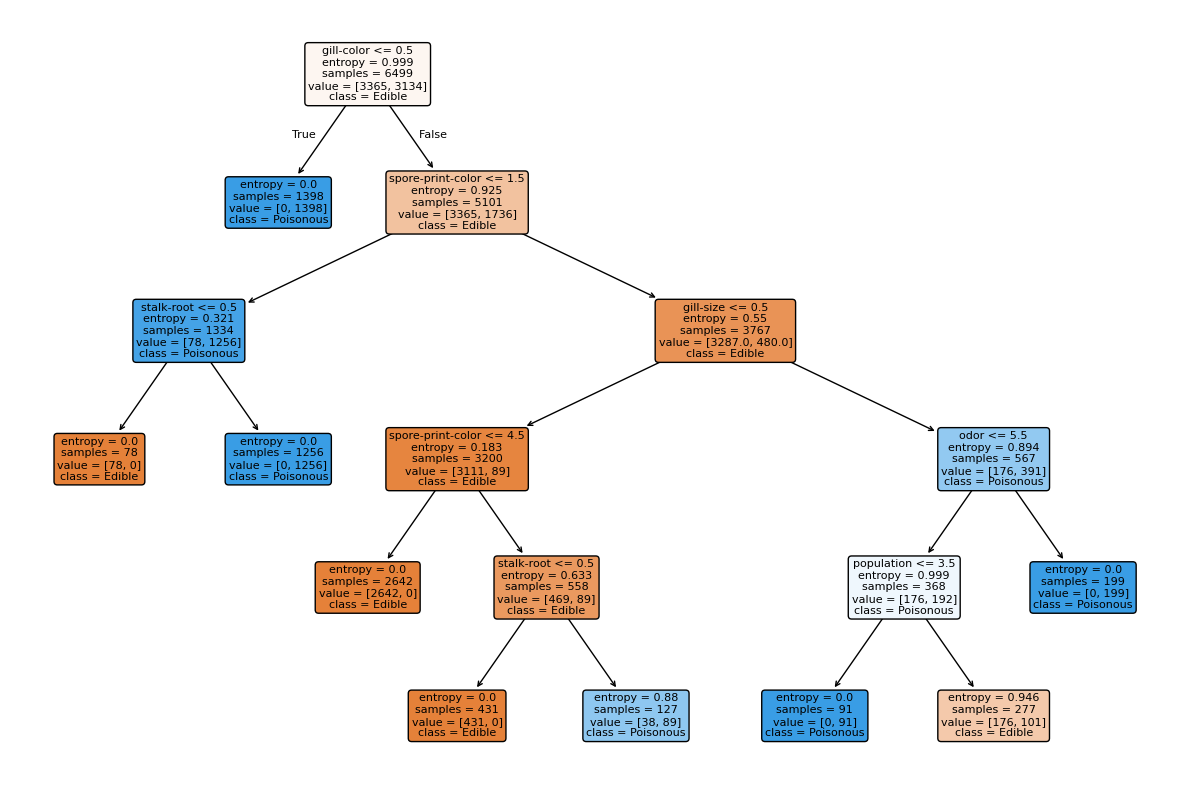

In [ ]:
# Decision Tree Visualization
plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Edible', 'Poisonous'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()


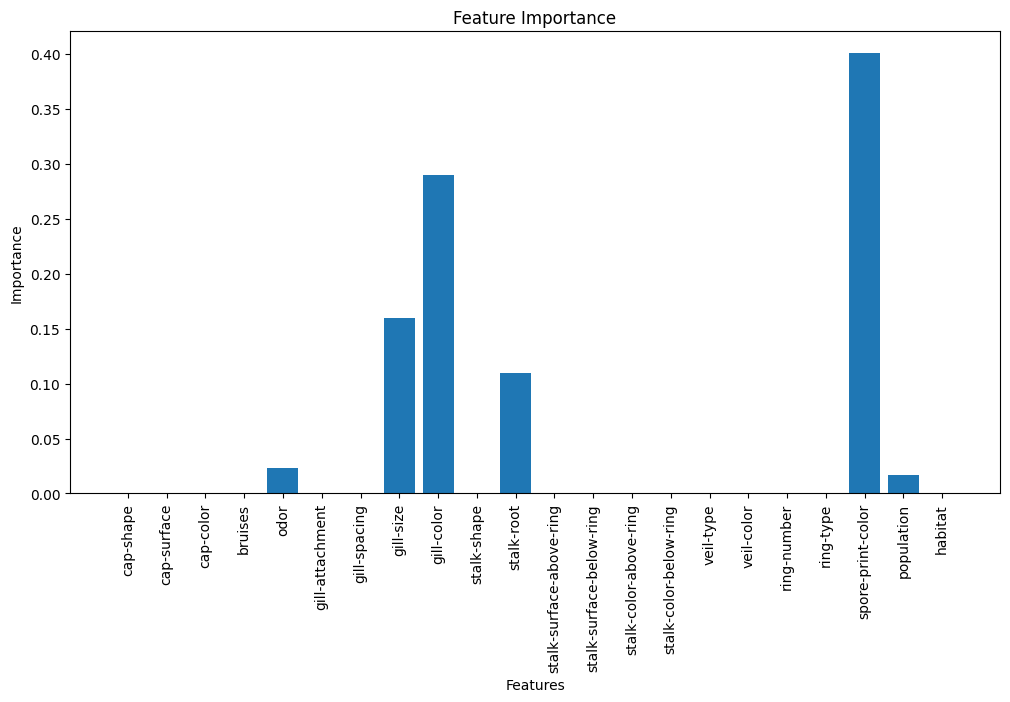

In [ ]:
# Feature Importance Graph
plt.figure(figsize=(12, 6))

plt.bar(X.columns, model.feature_importances_)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=90)
plt.show()

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy =", accuracy * 100, "%")


Accuracy = 97.72307692307692 %
